<a href="https://colab.research.google.com/github/Kai-Kun-1/AI-ML-course/blob/main/Plant_Disease_Classification_Using_Transfer_Learning_with_MobileNetV2_and_EfficientNetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plant Disease Classification Using Transfer Learning with MobileNetV2 and EfficientNetB0

### Why Plant Disease Detection is Important
Timely and accurate plant disease detection is crucial for maintaining food security, maximizing agricultural yield, and minimizing economic losses (external knowledge). Early identification allows farmers to treat outbreaks before they spread, reducing the reliance on broad-spectrum pesticides. Your project directly addresses this real-world need by classifying 15 different health and disease states across vital crops, including various blights, spots, and viruses affecting peppers, potatoes, and tomatoes. The dataset utilizes 20,638 images, reflecting the massive scale of monitoring required in actual agricultural settings.

### Why Deep Learning is Suitable
Deep learning models are highly suitable for this task because they automatically learn and extract complex visual features from raw images, such as the distinct textures and patterns of leaf mold or bacterial spots (external knowledge). By leveraging transfer learning, the models utilize pre-trained "imagenet" weights to effectively analyze plant leaves without needing to train from scratch. The sources demonstrate the power of this approach; despite the dataset being highly imbalanced (with a 21.11:1 imbalance ratio), the deep learning models achieved impressive overall validation accuracies between 92.8% and 93.3%.

### Why MobileNet and EfficientNetB0 Were Chosen
In practical agricultural deployments, models often need to run offline on edge devices like smartphones or field drones, which have limited computational power and memory. MobileNet and EfficientNetB0 are architectures designed specifically to optimize the trade-off between high diagnostic accuracy and computational efficiency (external knowledge). The sources confirm their lightweight, highly efficient nature: the MobileNet model requires only 3,244,239 parameters, while EfficientNet requires just 4,068,786 parameters. Despite their small parameter footprints, they deliver excellent, robust performance, with both models achieving high F1-scores of approximately 0.93.

# Environment Setup and Library Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
import warnings
warnings.filterwarnings('ignore')

# Configuration Variables and Directory Creation

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# (DATASET_PATH line has been removed from here!)

IMG_SIZE = 224
BATCH_SIZE = 32
# EPOCHS = 20
EPOCHS = 10
VALIDATION_SPLIT = 0.2

os.makedirs("eda_results", exist_ok=True)
os.makedirs("metrics_results", exist_ok=True)
os.makedirs("model_checkpoints", exist_ok=True)

# Loading the PlantVillage Dataset

In [3]:
# 1. Install kagglehub just in case your environment doesn't have it yet
!pip install kagglehub -q

import os
import tensorflow as tf
import kagglehub  # <-- This is the line that was missing and caused the NameError!

print("Downloading dataset via kagglehub...")

# 2. Download the dataset using kagglehub
download_path = kagglehub.dataset_download("emmarex/plantdisease")
print("Base downloaded path:", download_path)

# 3. Set the DATASET_PATH to the specific PlantVillage folder inside the download
DATASET_PATH = os.path.join(download_path, "PlantVillage")
print("Exact image path:", DATASET_PATH)

# 4. Load the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# 5. Load the validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# 6. Extract and print class names
class_names = sorted(train_ds.class_names)
num_classes = len(class_names)

print(f"Dataset loaded successfully")
print(f"Number of classes: {num_classes}")
print(f"\nClass names:")
for i, cls in enumerate(class_names, 1):
    print(f"  {i:2d}. {cls}")

Using Colab cache for faster access to the 'plantdisease' dataset.
Base downloaded path: /kaggle/input/plantdisease
Exact image path: /kaggle/input/plantdisease/PlantVillage
Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Dataset loaded successfully
Number of classes: 15

Class names:
   1. Pepper__bell___Bacterial_spot
   2. Pepper__bell___healthy
   3. Potato___Early_blight
   4. Potato___Late_blight
   5. Potato___healthy
   6. Tomato_Bacterial_spot
   7. Tomato_Early_blight
   8. Tomato_Late_blight
   9. Tomato_Leaf_Mold
  10. Tomato_Septoria_leaf_spot
  11. Tomato_Spider_mites_Two_spotted_spider_mite
  12. Tomato__Target_Spot
  13. Tomato__Tomato_YellowLeaf__Curl_Virus
  14. Tomato__Tomato_mosaic_virus
  15. Tomato_healthy


# Exploratory Data Analysis - Class Distribution Calculation

In [4]:
def get_class_distribution():
    class_counts = {}
    for class_name in class_names:
        class_path = os.path.join(DATASET_PATH, class_name)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            class_counts[class_name] = count
    return class_counts

class_distribution = get_class_distribution()
total_samples = sum(class_distribution.values())

print(f"\nTotal samples: {total_samples:,}")
print(f"\nSamples per class (sorted by count):")
print("-" * 60)
print(f"{'Class Name':<40} {'Count':>8} {'Percentage':>10}")
print("-" * 60)

for class_name, count in sorted(class_distribution.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / total_samples) * 100
    print(f"{class_name:<40} {count:>8} {percentage:>9.2f}%")

print("-" * 60)

# Class balance analysis
max_count = max(class_distribution.values())
min_count = min(class_distribution.values())
imbalance_ratio = max_count / min_count

print(f"\nClass Balance Statistics:")
print(f"Max samples: {max_count:,}")
print(f"Min samples: {min_count:,}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 5:
    print(f"Dataset is HIGHLY IMBALANCED - Weighted loss may be beneficial")
elif imbalance_ratio > 2:
    print(f"Dataset is moderately imbalanced")
else:
    print(f"Dataset is relatively balanced")


Total samples: 20,638

Samples per class (sorted by count):
------------------------------------------------------------
Class Name                                  Count Percentage
------------------------------------------------------------
Tomato__Tomato_YellowLeaf__Curl_Virus        3208     15.54%
Tomato_Bacterial_spot                        2127     10.31%
Tomato_Late_blight                           1909      9.25%
Tomato_Septoria_leaf_spot                    1771      8.58%
Tomato_Spider_mites_Two_spotted_spider_mite     1676      8.12%
Tomato_healthy                               1591      7.71%
Pepper__bell___healthy                       1478      7.16%
Tomato__Target_Spot                          1404      6.80%
Potato___Early_blight                        1000      4.85%
Potato___Late_blight                         1000      4.85%
Tomato_Early_blight                          1000      4.85%
Pepper__bell___Bacterial_spot                 997      4.83%
Tomato_Leaf_Mold     

# Visualizing Class Distributions


[2.2] Visualizing class distribution...


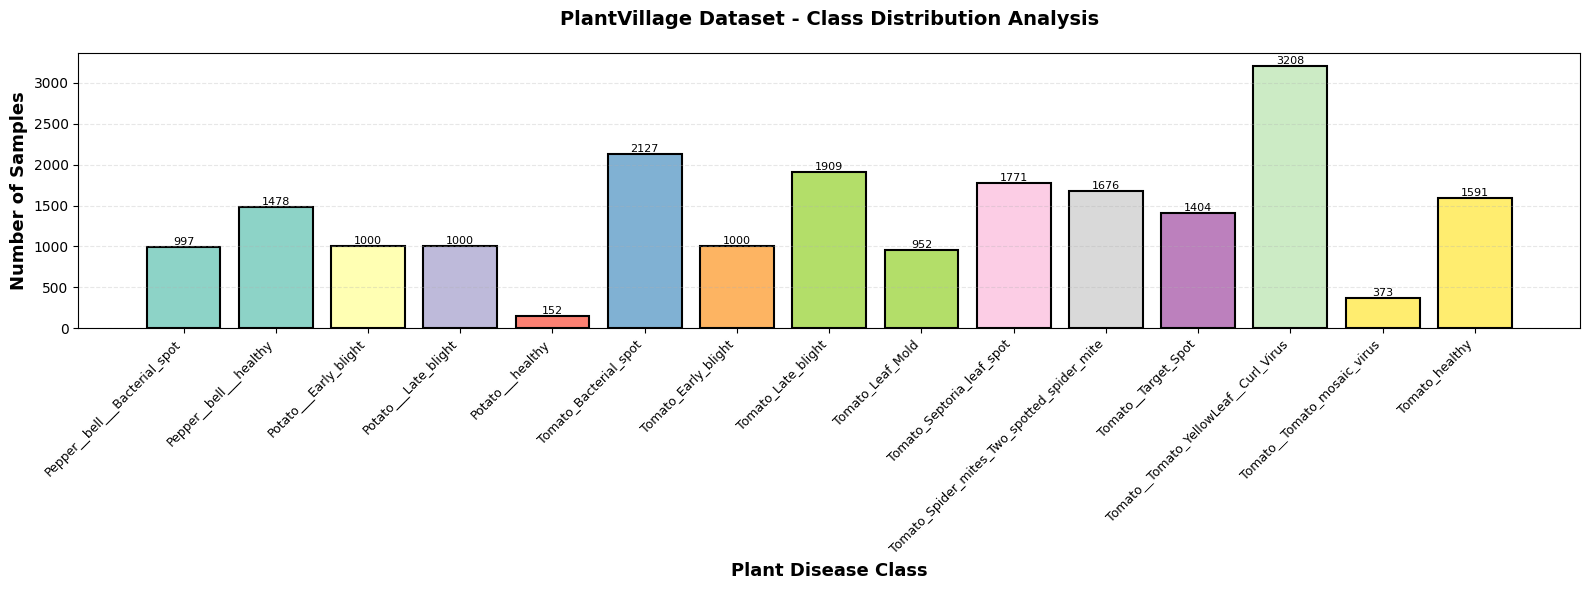

Saved: eda_results/01_class_distribution.png


In [5]:
print("\n[2.2] Visualizing class distribution...")

fig, ax = plt.subplots(figsize=(16, 6))

classes = list(class_distribution.keys())
counts = list(class_distribution.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(classes)))

bars = ax.bar(range(len(classes)), counts, color=colors, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Plant Disease Class', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=13, fontweight='bold')
ax.set_title('PlantVillage Dataset - Class Distribution Analysis', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('eda_results/01_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: eda_results/01_class_distribution.png")

# Data Preprocessing and Image Augmentation

In [6]:
print("\nData Augmentation and Preprocessing...")

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# Augmentation pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

print(f"Train batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")


Data Augmentation and Preprocessing...
Train batches: 516
Validation batches: 129


# Defining and Instantiating the Transfer Learning Models

In [7]:
print("\nBuilding Transfer Learning Models...")

def build_model(base_model_fn, model_name, num_classes, preprocess_fn=None):
    base_model = base_model_fn(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)

    # preprocess (model bazlı)
    if preprocess_fn is not None:
        x = preprocess_fn(x)

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name=model_name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("\nBuilding models...")

mobilenet = build_model(
    tf.keras.applications.MobileNet,
    "MobileNet",
    num_classes,
    preprocess_fn=tf.keras.applications.mobilenet.preprocess_input
)
print(f"MobileNet: {mobilenet.count_params():,} parameters")

efficientnet = build_model(
    tf.keras.applications.EfficientNetB0,
    "EfficientNet",
    num_classes,
    preprocess_fn=tf.keras.applications.efficientnet.preprocess_input
)
print(f"EfficientNet: {efficientnet.count_params():,} parameters")


models_list = [
    ("MobileNet", mobilenet),
    ("EfficientNet", efficientnet)
]

print("\nAll models created successfully")


Building Transfer Learning Models...

Building models...
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNet: 3,244,239 parameters
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNet: 4,068,786 parameters

All models created successfully


# Model Training Execution

In [8]:
print("\nTraining Models...")

def train_model(model):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"model_checkpoints/{model.name}.h5",
            save_best_only=True,
            monitor="val_accuracy",
            verbose=0
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    return history

# Train all models
histories = {}

print("Training MobileNet...")
histories["MobileNet"] = train_model(mobilenet)
print("\n" + "="*60 + "\n")

print("Training EfficientNet...")
histories["EfficientNet"] = train_model(efficientnet)
print("\n" + "="*60 + "\n")


Training Models...
Training MobileNet...
Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5590 - loss: 1.4598

516/516 ━━━━━━━━━━━━━━━━━━━━ 86s 129ms/step - accuracy: 0.7064 - loss: 0.9364 - val_accuracy: 0.8725 - val_loss: 0.4271
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8352 - loss: 0.4972

516/516 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - accuracy: 0.8431 - loss: 0.4721 - val_accuracy: 0.9065 - val_loss: 0.3155
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8687 - loss: 0.4129

516/516 ━━━━━━━━━━━━━━━━━━━━ 40s 66ms/step - accuracy: 0.8668 - loss: 0.4060 - val_accuracy: 0.9116 - val_loss: 0.2812
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8771 - loss: 0.3671

516/516 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.8761 - loss: 0.3642 - val_accuracy: 0.9130 - val_loss: 0.2614
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.8838 - loss: 0.3437 - val_accuracy: 0.9091 - val_loss: 0.2602
Epoch 6/10
515/516 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8900 - loss: 0.3304

...

516/516 ━━━━━━━━━━━━━━━━━━━━ 51s 99ms/step - accuracy: 0.8852 - loss: 0.3772 - val_accuracy: 0.8868 - val_loss: 0.3497
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8853 - loss: 0.3618

516/516 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.8872 - loss: 0.3549 - val_accuracy: 0.8980 - val_loss: 0.3145
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8960 - loss: 0.3343

516/516 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.8971 - loss: 0.3281 - val_accuracy: 0.9007 - val_loss: 0.3034
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9030 - loss: 0.3082

516/516 ━━━━━━━━━━━━━━━━━━━━ 50s 98ms/step - accuracy: 0.9030 - loss: 0.3070 - val_accuracy: 0.9050 - val_loss: 0.2897
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9071 - loss: 0.2913

516/516 ━━━━━━━━━━━━━━━━━━━━ 83s 99ms/step - accuracy: 0.9058 - loss: 0.2948 - val_accuracy: 0.9166 - val_loss: 0.2543
Epoch 9/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 50s 97ms/step - accuracy: 0.9048 - loss: 0.2946 - val_accuracy: 0.9079 - val_loss: 0.2701
Epoch 10/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 50s 97ms/step - accuracy: 0.9061 - loss: 0.2867 - val_accuracy: 0.9145 - val_loss: 0.2559
Restoring model weights from the end of the best epoch: 8.




# Plotting Training Accuracy and Loss Histories


Visualizing Training History...


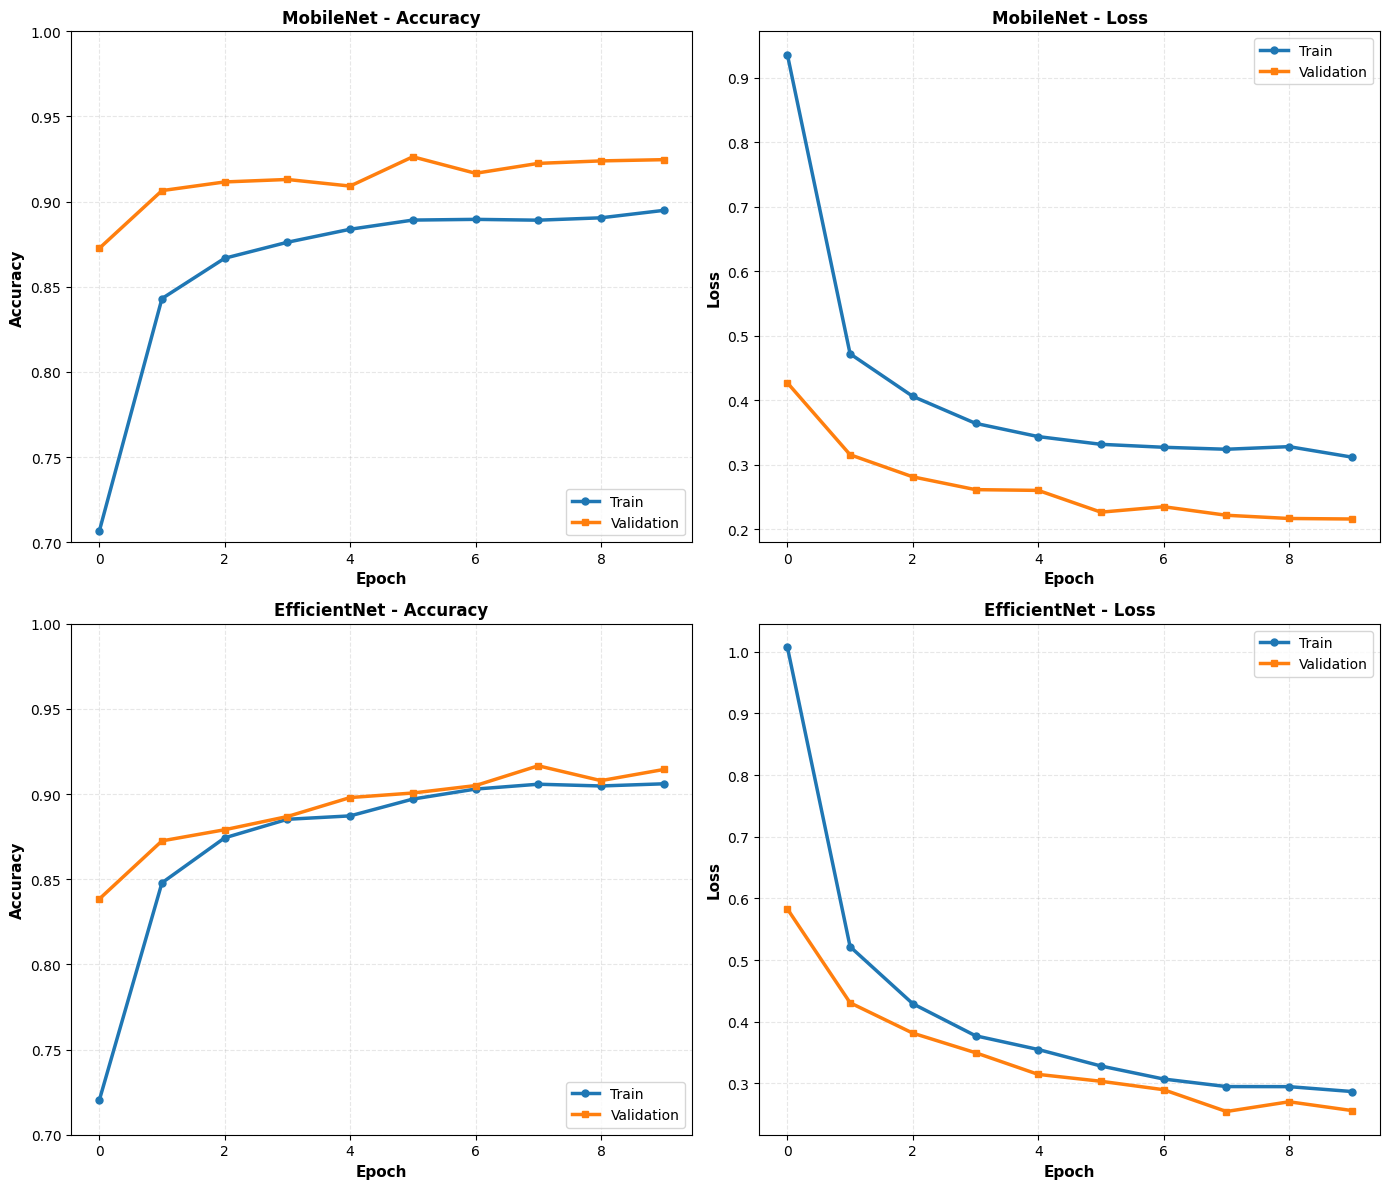

Saved: metrics_results/01_training_history.png


In [9]:
print("\nVisualizing Training History...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, (model_name, history) in enumerate(histories.items()):
    # Accuracy
    axes[idx, 0].plot(history.history['accuracy'], label='Train', linewidth=2.5, marker='o', markersize=5)
    axes[idx, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2.5, marker='s', markersize=5)
    axes[idx, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
    axes[idx, 0].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    axes[idx, 0].set_title(f'{model_name} - Accuracy', fontsize=12, fontweight='bold')
    axes[idx, 0].legend(fontsize=10, loc='lower right')
    axes[idx, 0].grid(True, alpha=0.3, linestyle='--')
    axes[idx, 0].set_ylim([0.7, 1.0])

    # Loss
    axes[idx, 1].plot(history.history['loss'], label='Train', linewidth=2.5, marker='o', markersize=5)
    axes[idx, 1].plot(history.history['val_loss'], label='Validation', linewidth=2.5, marker='s', markersize=5)
    axes[idx, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
    axes[idx, 1].set_ylabel('Loss', fontsize=11, fontweight='bold')
    axes[idx, 1].set_title(f'{model_name} - Loss', fontsize=12, fontweight='bold')
    axes[idx, 1].legend(fontsize=10, loc='upper right')
    axes[idx, 1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('metrics_results/01_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: metrics_results/01_training_history.png")

# Model Evaluation

In [10]:
print("\nDetailed Model Evaluation...")

def get_predictions_and_labels(model, dataset):
    all_preds = []
    all_labels = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_preds.extend(np.argmax(preds, axis=1))
        all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

evaluation_results = {}

for model_name, model in models_list:
    print(f"\nEvaluating {model_name}...")

    # Basic metrics
    loss, accuracy = model.evaluate(val_ds, verbose=0)

    # Get predictions
    y_pred, y_true = get_predictions_and_labels(model, val_ds)

    # Detailed metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    # Per-class metrics
    per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(num_classes), zero_division=0
    )

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))

    evaluation_results[model_name] = {
        'loss': loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'y_pred': y_pred,
        'y_true': y_true,
        'confusion_matrix': cm,
        'per_class_precision': per_class_precision,
        'per_class_recall': per_class_recall,
        'per_class_f1': per_class_f1,
        'per_class_support': per_class_support
    }

    print(f"{model_name} evaluation completed")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")


Detailed Model Evaluation...

Evaluating MobileNet...
MobileNet evaluation completed
Accuracy:  0.9263
Precision: 0.9282
Recall:    0.9263
F1-Score:  0.9265

Evaluating EfficientNet...
EfficientNet evaluation completed
Accuracy:  0.9166
Precision: 0.9219
Recall:    0.9166
F1-Score:  0.9164


# Results


Creating Comparison Visualizations...


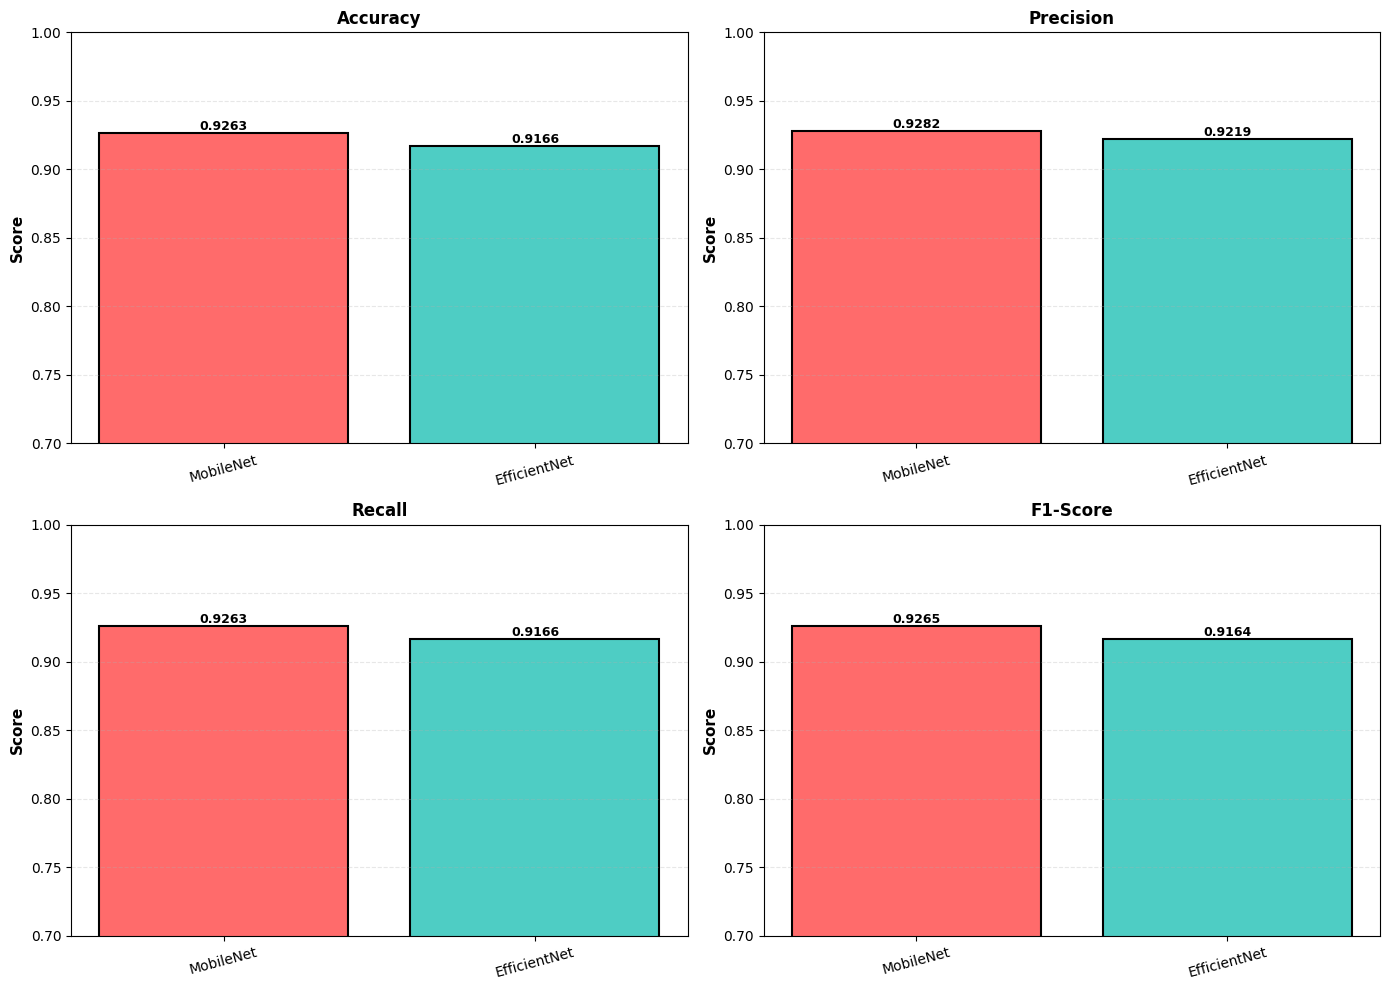

Saved: metrics_results/02_metrics_comparison.png


In [11]:
print("\nCreating Comparison Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

model_names_short = [name for name, _ in models_list]

metrics_to_plot = [
    ('Accuracy', 'accuracy'),
    ('Precision', 'precision'),
    ('Recall', 'recall'),
    ('F1-Score', 'f1')
]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, (metric_label, metric_key) in enumerate(metrics_to_plot):
    values = [evaluation_results[name][metric_key] for name, _ in models_list]

    bars = axes[idx].bar(model_names_short, values, color=colors, edgecolor='black', linewidth=1.5)
    axes[idx].set_ylabel('Score', fontsize=11, fontweight='bold')
    axes[idx].set_title(metric_label, fontsize=12, fontweight='bold')
    axes[idx].set_ylim([0.70, 1.0])
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].tick_params(axis='x', rotation=15)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_results/02_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: metrics_results/02_metrics_comparison.png")

#Detailed Metrics Tables and Summary Report

In [12]:
print("\nGenerating Detailed Metrics Tables...")

for model_name, model in models_list:
    results = evaluation_results[model_name]

    # Per-class metrics
    per_class_df = pd.DataFrame({
        'Class': class_names,
        'Precision': results['per_class_precision'],
        'Recall': results['per_class_recall'],
        'F1-Score': results['per_class_f1'],
        'Support': results['per_class_support'].astype(int)
    })

    # Overall metrics
    overall_df = pd.DataFrame({
        'Class': ['Weighted Average'],
        'Precision': [results['precision']],
        'Recall': [results['recall']],
        'F1-Score': [results['f1']],
        'Support': [int(results['per_class_support'].sum())]
    })

    final_df = pd.concat([per_class_df, overall_df], ignore_index=True)

    csv_name = model_name.replace(" ", "_").replace("-", "_")
    final_df.to_csv(f'metrics_results/{csv_name}_detailed_metrics.csv', index=False)

    print(f"\n {model_name} - Detailed Metrics")
    print(final_df.to_string(index=False))


Generating Detailed Metrics Tables...

 MobileNet - Detailed Metrics
                                      Class  Precision   Recall  F1-Score  Support
              Pepper__bell___Bacterial_spot   0.994505 0.905000  0.947644      200
                     Pepper__bell___healthy   0.926380 1.000000  0.961783      302
                      Potato___Early_blight   0.989247 0.973545  0.981333      189
                       Potato___Late_blight   0.905941 0.973404  0.938462      188
                           Potato___healthy   0.933333 0.903226  0.918033       31
                      Tomato_Bacterial_spot   0.949541 0.938776  0.944128      441
                        Tomato_Early_blight   0.821990 0.821990  0.821990      191
                         Tomato_Late_blight   0.925697 0.876833  0.900602      341
                           Tomato_Leaf_Mold   0.898305 0.859459  0.878453      185
                  Tomato_Septoria_leaf_spot   0.910256 0.905612  0.907928      392
Tomato_Spider_mit

In [13]:
print("\n" + "="*80)
print("SUMMARY REPORT")
print("="*80)

summary_data = {
    'Model': [name for name, _ in models_list],
    'Parameters': [model.count_params() for _, model in models_list],
    'Accuracy': [evaluation_results[name]['accuracy'] for name, _ in models_list],
    'Precision': [evaluation_results[name]['precision'] for name, _ in models_list],
    'Recall': [evaluation_results[name]['recall'] for name, _ in models_list],
    'F1-Score': [evaluation_results[name]['f1'] for name, _ in models_list],
    'Loss': [evaluation_results[name]['loss'] for name, _ in models_list]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('metrics_results/00_model_summary.csv', index=False)

print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)


SUMMARY REPORT

       Model  Parameters  Accuracy  Precision   Recall  F1-Score     Loss
   MobileNet     3244239  0.926339   0.928235 0.926339  0.926458 0.226409
EfficientNet     4068786  0.916646   0.921890 0.916646  0.916439 0.254339

